<a href="https://colab.research.google.com/github/MageroOduor/ML/blob/main/Loan_Default_Prediction_Zindi_Challenge_2_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [21]:
#Upload your CSV files into Colab first.
#from google.colab import files
#uploaded = files.upload()
dem = pd.read_csv("traindemographics.csv")
perf = pd.read_csv("trainperf.csv")
prev = pd.read_csv("trainprevloans.csv")

In [22]:
#Explore the data
#A. Shape
print("Demographics shape:", dem.shape)
print("Performance shape:", perf.shape)
print("Previous loans shape:", prev.shape)


Demographics shape: (4346, 9)
Performance shape: (4368, 10)
Previous loans shape: (18183, 12)


In [23]:
#B. First rows
dem.head()
perf.head()
prev.head()


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.0,11500.0,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.0,11500.0,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


In [24]:
#Data types

dem.info()
perf.info()
prev.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4346 non-null   object 
 1   birthdate                   4346 non-null   object 
 2   bank_account_type           4346 non-null   object 
 3   longitude_gps               4346 non-null   float64
 4   latitude_gps                4346 non-null   float64
 5   bank_name_clients           4346 non-null   object 
 6   bank_branch_clients         51 non-null     object 
 7   employment_status_clients   3698 non-null   object 
 8   level_of_education_clients  587 non-null    object 
dtypes: float64(2), object(7)
memory usage: 305.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerid   

In [25]:
#Summary statistics

perf.describe()


,systemloanid,loannumber,loanamount,totaldue,termdays
count,4.368000e+03,4368.000000,4368.000000,4368.000000,4368.000000
mean,3.019810e+08,5.172390,17809.065934,21257.377679,29.261676
std,1.343115e+04,3.653569,10749.694571,11943.510416,11.512519
min,3.019585e+08,2.000000,10000.000000,10000.000000,15.000000
25%,3.019691e+08,2.000000,10000.000000,13000.000000,30.000000
50%,3.019801e+08,4.000000,10000.000000,13000.000000,30.000000
75%,3.019935e+08,7.000000,20000.000000,24500.000000,30.000000
max,3.020040e+08,27.000000,60000.000000,68100.000000,90.000000


In [26]:
#Target distribution
perf["good_bad_flag"].value_counts()


,count
good_bad_flag,
Good,3416
Bad,952


In [27]:
#Handling missing data
#A: Identify missing values
dem.isnull().sum()
perf.isnull().sum()
prev.isnull().sum()

#Handling strategy

#For numeric columns → fill with median

#For categorical columns → fill with mode

#For date columns → convert first, then handle
#📌 Why median?: Because loan data is usually skewed. Median is more robust than mean.

#Example:

# Convert dates first
prev["firstduedate"] = pd.to_datetime(prev["firstduedate"], errors="coerce")
prev["firstrepaiddate"] = pd.to_datetime(prev["firstrepaiddate"], errors="coerce")

dem["birthdate"] = pd.to_datetime(dem["birthdate"], errors="coerce")

# Fill numeric columns
for col in dem.select_dtypes(include=np.number).columns:
    dem[col].fillna(dem[col].median(), inplace=True)

# Fill categorical columns
for col in dem.select_dtypes(include="object").columns:
    dem[col].fillna(dem[col].mode()[0], inplace=True)



/tmp/ipython-input-210633370.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dem[col].fillna(dem[col].median(), inplace=True)
/tmp/ipython-input-210633370.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [36]:
#Explore engineered data
data.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,...,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,avg_prev_loan,late_payment_rate,avg_days_late,age,loan_ratio,long_term
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,...,Diamond Bank,OGBA,Permanent,Post-Graduate,18181.818182,0.363636,6.818182,53.0,1.1500,0
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good,...,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,0.000000,0.000000,0.000000,40.0,1.1500,0
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good,...,EcoBank,OGBA,Permanent,Graduate,10000.000000,0.500000,5.000000,41.0,1.1125,0
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good,...,First Bank,OGBA,Permanent,Graduate,10000.000000,1.000000,7.500000,48.0,1.1500,0
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good,...,GT Bank,OGBA,Permanent,Primary,18750.000000,0.000000,0.000000,39.0,1.1000,0


In [35]:
#Feature engineering

# Merge data (moved from previous cell to ensure 'data' is defined)
data = perf.merge(dem, on="customerid", how="left")

# Ensure date columns are correctly converted to datetime objects
prev["firstduedate"] = pd.to_datetime(prev["firstduedate"], errors="coerce")
prev["firstrepaiddate"] = pd.to_datetime(prev["firstrepaiddate"], errors="coerce")

prev["late_payment"] = (prev["firstrepaiddate"] > prev["firstduedate"]).astype(int)

prev["days_late"] = (prev["firstrepaiddate"] - prev["firstduedate"]).dt.days
prev["days_late"] = prev["days_late"].clip(lower=0)

prev_features = prev.groupby("customerid").agg({
    "loanamount": "mean",
    "late_payment": "mean",
    "days_late": "mean"
}).reset_index()

prev_features.columns = [
    "customerid",
    "avg_prev_loan",
    "late_payment_rate",
    "avg_days_late"
]
#merge
data = data.merge(prev_features, on="customerid", how="left")

# Ensure birthdate is datetime before calculating age
data["birthdate"] = pd.to_datetime(data["birthdate"], errors="coerce")

#🔸 Demographic Features
data["age"] = 2025 - data["birthdate"].dt.year

#🔸 Loan Features
data["loan_ratio"] = data["totaldue"] / data["loanamount"]
data["long_term"] = (data["termdays"] > 30).astype(int)

#🔸 Fill numeric missing values safely
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(0)

In [30]:
#Data wrangling
analysis_data = data[[
    "loanamount",
    "totaldue",
    "termdays",
    "age",
    "avg_prev_loan",
    "late_payment_rate",
    "good_bad_flag"
]]
analysis_data.groupby("good_bad_flag")["loanamount"].mean()
analysis_data.groupby("good_bad_flag")["late_payment_rate"].mean()



,late_payment_rate
good_bad_flag,
Bad,0.528214
Good,0.317239


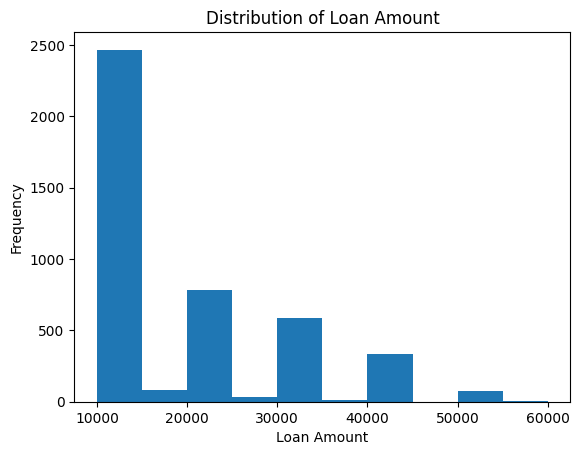

In [31]:
#Data Visualisation:
#📊 1️⃣ Histogram – Loan Amount
plt.figure()
plt.hist(data["loanamount"])
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()



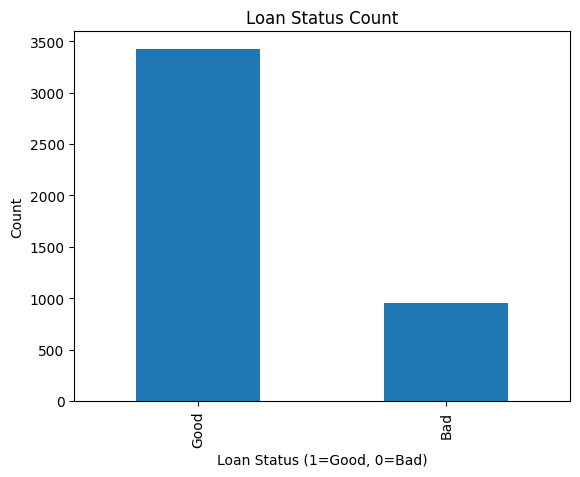

In [32]:
#📊 2️⃣ Bar Chart – Good vs Bad Loans

data["good_bad_flag"].value_counts().plot(kind="bar")
plt.title("Loan Status Count")
plt.xlabel("Loan Status (1=Good, 0=Bad)")
plt.ylabel("Count")
plt.show()


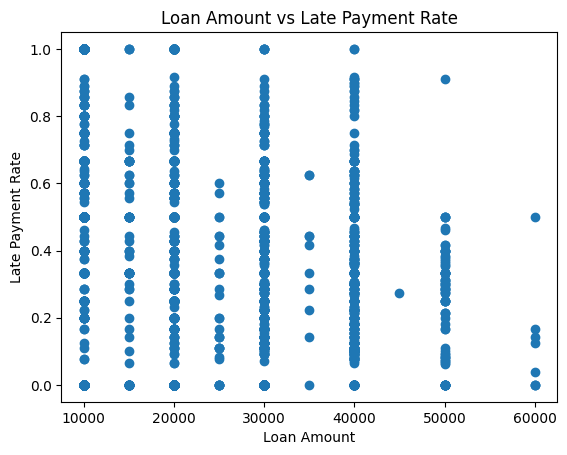

In [33]:
#📊 3️⃣ Scatter Plot – Loan Amount vs Late Payment
plt.figure()
plt.scatter(data["loanamount"], data["late_payment_rate"])
plt.title("Loan Amount vs Late Payment Rate")
plt.xlabel("Loan Amount")
plt.ylabel("Late Payment Rate")
plt.show()


In [37]:
#Data Modeling

# Prepare y (target variable) first
y = data["good_bad_flag"].map({"Good": 1, "Bad": 0})

# Prepare X (features)
# Drop the target column and other non-feature columns
X = data.drop(["customerid", "systemloanid", "approveddate", "creationdate", "good_bad_flag", "birthdate"], axis=1)

# Encode remaining categorical variables in X
X = pd.get_dummies(X, drop_first=True)

#Split:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train model:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Error Rate:", 1 - accuracy_score(y_test, pred))

Accuracy: 0.7831050228310502
Error Rate: 0.2168949771689498


In [39]:
#Submission file

# Load test data
test_perf = pd.read_csv("testperf.csv")
test_dem = pd.read_csv("testdemographics.csv")
test_prev = pd.read_csv("testprevloans.csv")

# Merge test data
test_data = test_perf.merge(test_dem, on="customerid", how="left")

# Ensure date columns are correctly converted to datetime objects for test_prev
test_prev["firstduedate"] = pd.to_datetime(test_prev["firstduedate"], errors="coerce")
test_prev["firstrepaiddate"] = pd.to_datetime(test_prev["firstrepaiddate"], errors="coerce")

# Feature engineering for test_prev
test_prev["late_payment"] = (test_prev["firstrepaiddate"] > test_prev["firstduedate"]).astype(int)
test_prev["days_late"] = (test_prev["firstrepaiddate"] - test_prev["firstduedate"]).dt.days
test_prev["days_late"] = test_prev["days_late"].clip(lower=0)

test_prev_features = test_prev.groupby("customerid").agg({
    "loanamount": "mean",
    "late_payment": "mean",
    "days_late": "mean"
}).reset_index()
test_prev_features.columns = [
    "customerid",
    "avg_prev_loan",
    "late_payment_rate",
    "avg_days_late"
]

# Merge previous loan features into test_data
test_data = test_data.merge(test_prev_features, on="customerid", how="left")

# Ensure birthdate is datetime before calculating age for test_data
test_data["birthdate"] = pd.to_datetime(test_data["birthdate"], errors="coerce")

# Demographic Features for test_data
test_data["age"] = 2025 - test_data["birthdate"].dt.year

# Loan Features for test_data
test_data["loan_ratio"] = test_data["totaldue"] / test_data["loanamount"]
test_data["long_term"] = (test_data["termdays"] > 30).astype(int)

# Fill numeric missing values safely for test_data
numeric_cols_test = test_data.select_dtypes(include=np.number).columns
test_data[numeric_cols_test] = test_data[numeric_cols_test].fillna(0)

# Prepare test_X (features) - drop non-feature columns
test_X = test_data.drop([
    "customerid",
    "systemloanid",
    "approveddate",
    "creationdate",
    "referredby", # referredby also needs to be dropped from test data as it's not in X_train
    "birthdate"
], axis=1)

# Align columns with training data after one-hot encoding
# This ensures that test_X has the same columns in the same order as X_train
# We need to apply get_dummies and then reindex to match X's columns
test_X = pd.get_dummies(test_X, drop_first=True)

# Reindex test_X to have the same columns as X_train, filling missing with 0
test_X = test_X.reindex(columns = X_train.columns, fill_value=0)

# Make predictions
test_predictions = model.predict(test_X)

# Create submission file
submission = pd.DataFrame({
    "customerid": test_perf["customerid"], # Use customerid from original test_perf
    "Good_Bad_flag": test_predictions
})

# Map numerical predictions back to 'Good'/'Bad'
submission["Good_Bad_flag"] = submission["Good_Bad_flag"].map({1: "Good", 0: "Bad"})

submission.to_csv("submission.csv", index=False)

from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>